# Chapter 4 | Training Models

In this chapter:
- Different ways of fitting a Linear Regression
- A Generic Optimization Algorithm: the Gradient Descent

## Linear Regression
A **Linear Regression Model** makes predictions by computing a **weighted sum** of the **input features** plus a **constant term (bias** or **intercept)**:
$$ \hat y = \theta_0 + \theta_1x_1 + \theta_2x_2 + ... + \theta_nx_n $$
where:
- $\hat y$ -> predicted value;
- $n$ -> number of features;
- $x_i$ -> $i^{th}$ feature;
- $\theta_j$ -> $j^{th}$ model parameter.

The above formula can be written in a **vectorized form** aswell:
$$ \hat y = h_{\theta} (x) = \theta \cdot x$$
where:
- $h_{\theta}$ -> hypothesis function using the model's parameters $\theta$;
- $\theta$ -> model's parameter vector (from $\theta_0$ to $\theta_n$);
- $x$ -> instance's feature vector (from $x_0$ to $x_n$);
- $0 \cdot x$ -> dot product of vectors (equal to $\theta_0x_0 + \theta_1x_1 + \theta_2x_2 + ... + \theta_nx_n $).

(Note how in ML, vectors are usually represented as **column vectors**, i.e., 2D arrays with a single column, so the above dot product may be expressed as matrix multiplication as $\theta^Tx$)

As we know, training a model means find its parameter that best fit the training set, so we need a metric that measures how well (or poorly) the model fits the training data. The most common metric for Linear Regression is the RMSE (Root Mean Squared Error), but considering that minimizing the MSE (Mean Squared Error) is easier and equivalent, we will focus on minimizing this.

(Note how training the model often uses a different loss function than the one we use to evaluate the final model; this is because some loss functions are easier to optimize and are still highly correlated with our final metric)

The formula of the MSE of a Linear Regression hypothesis $h_0$ on a training set $X$ is:

$$ MSE(X, h_{\theta}) = \frac{1}{m}\sum_i^m(\theta^Tx^{(i)} - y^{(i)})^2 $$
(for simplicity we will write $MSE(\theta)$ instead of $MSE(X, h_{\theta})$)

### The Normal Equation
One way of finding $\theta$ minimizing $MSE$ is by using the so called **closed-form solution**, which is basically a mathematical equation that gives directly the result; this equation is called the **Normal Equation**:

$$ \hat \theta = (X^TX)^{-1}X^Ty$$
where:
- $\hat\theta$ -> value of $\theta$ minimizing the cost function;
- $y$ -> vector of target values (from $y^{(1)}$ to $y^{(m)}$)

Let's try to find $\theta$ for some synthetic linear data; we will generate data using the function:

$$ y = 4 + 3 x_1 + Gn$$
where $Gn$ is some Gaussian noise.

Text(0, 0.5, 'y')

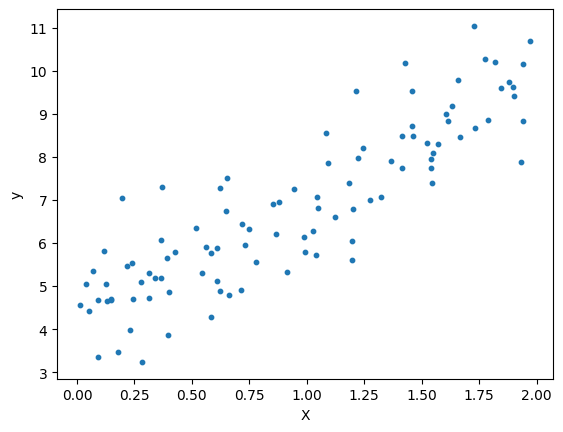

In [1]:
import matplotlib.pyplot as plt
import numpy as np 

np.random.seed(42)
m = 100                                 # number of instances
X = 2 * np.random.rand(m, 1)            # column vector
y = 4 + 3 * X + np.random.randn(m, 1)   # column vector
plt.scatter(X, y, s = 10)
plt.xlabel('X')
plt.ylabel('y')

Let's now use the Normal Formula to compute $\hat\theta$:

In [2]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

NOTE: the @ operator performs matrix multiplication and it is supported by a lot of libraries like NumPy, TensorFlow, PyTorch...

Let's now check the parameters of the equation we found:

In [3]:
theta_best

array([[4.21509616],
       [2.77011339]])

We got $\theta_0 = 4.215$ (instead of 4) and $theta_1 = 2.770$ (instead of 3); these are very close, but the introduced noise made it impossible to recover the exact parameters (smaller and noisier the dataset is, harder it is to get the parameters).

Let's use this $\hat \theta$ to make predictions:

In [4]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

Let's plot the predictions' line:

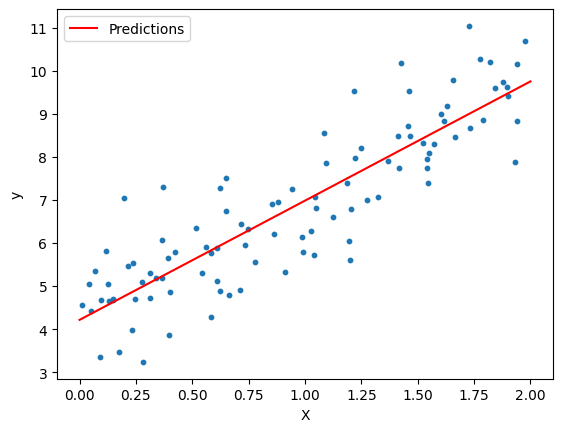

In [5]:
plt.plot(X_new, y_predict, 'r-', label = 'Predictions')
plt.scatter(X, y, s=10)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### The Singular Value Decomposition (SVD) Approach
Another way of computing $\theta$ is the one adopted by scikit for example:

In [6]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [7]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

This last algorithm computes:

$$\hat \theta = X^+y$$


where:
- $X^+$: is the **pseudoinverse** (specifically the **Moore-Penrose inverse**) of $X$. 

This pseudoinverse is computed using **singular value decomposition (SVD)**, which is a matrix factorization technique that decompose the training set matrix $X$ into the multiplication of 3 matrices $U \Sigma V^T$; in the same way, the pseudoinverse of $X^+$ is computed as: 
$$X^+ = V \Sigma^+ U^T$$

where:
- $\Sigma^+$ is obtained by taking all values of $\Sigma$ smaller than a tiny threshold to zero, then replacing all nonzero values with their inverse and transposing the resulting matrix.

The main idea behind this is that performing Linear Regression with the last approach (using Pseudoinverse) instead of with Normal Equation (using inverse) is more efficient and stable, cause it works even if the matrix $X^TX$ is not invertible.

### Computational Complexity
- Normal Equation approach: from $O(n^{2.4})$ to $O(n^3)$ -> complexity comes from inverting $X^TX$;
- SVD approach: $O(n^2)$

(both approaches are still very fast at inference time)

### Gradient Descent
The **Gradient Descent** is a **generic optimimization algorithm** capable of finding optimal solutions to a wide range of problems. The general idea is to tweak parameters iteratively in order to minimize a **cost function** (it's like feeling the slope of the ground below your feet and go in the direction of the steepest slope to get to bottom of a valley).

More in depth, this algorithm starts with **Random Initialization** ($\theta$ is filled with random values); then, the algorithm tries to decrease the cost function by taking one baby step at a time until it **converges to a minimum** (the size of the step is the **Learning Rate** hyperparameter).

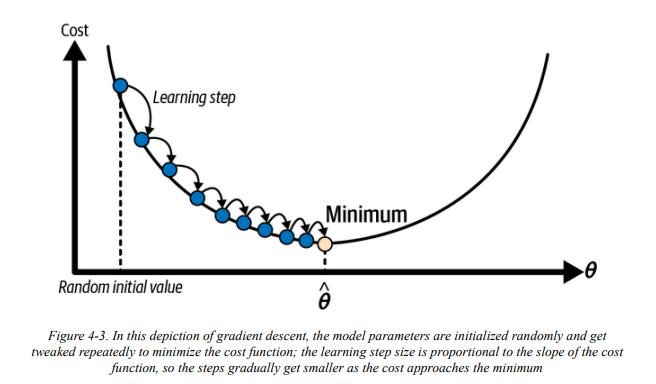

If the learning rate is too small, the algorithm could take too long time before convergence:

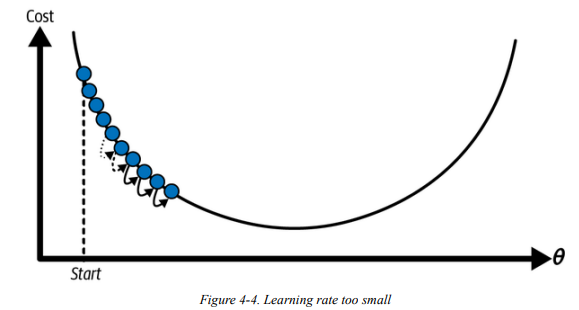

If the learning rate is too high, it could take to skip the minimum and diverge:

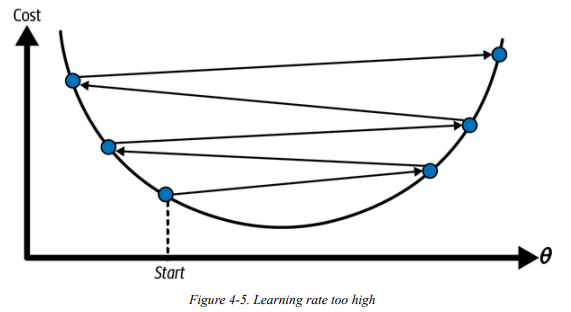

Of course, the shape of the cost function is a factor: MSE happens to be a **convex function** (i.e., has shape of a bowl), which means that there are no local minima, but just a global minimum -> this means that if learning rate is not too high and we wait enough, gradient descent will always approach closely to the global minimum.

While MSE has always the shape of a bowl, it may happen to be an elongated bowl:

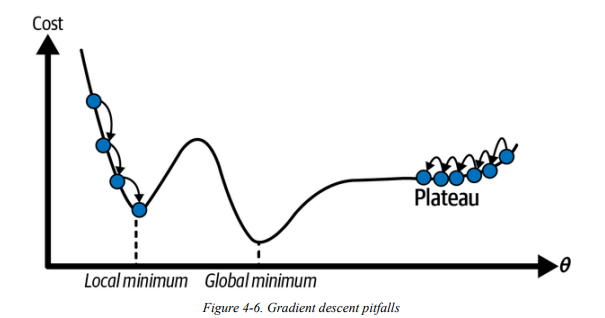

This happens when features have very different scales; below a comparison between GD with scaled features (left) and not-scaled features (right):

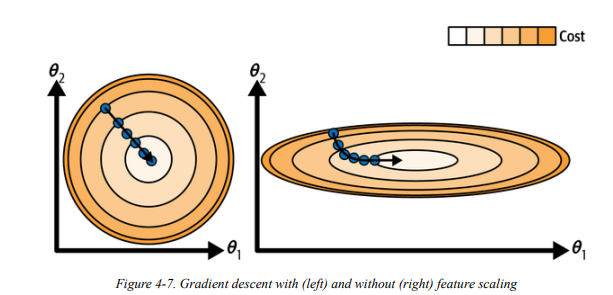

This lets us understand how scaling features helps GD converging faster to the global minimum.

#### Batch Gradient Descent
A first approach to Gradient Descent is to compute the **gradient** of the cost function with reguard to each model parameter $\theta_j$; this involves computing the **partial derivative** of the cost function with respect to each model parameter $\theta_j$, which basically tells us how much the cost function will change by changing $\theta_j$ a little bit:

$$ \frac{\partial}{\partial \theta_j} MSE (\theta) = \frac 2 m \sum_i^m (\theta^T x^{(i)} - y^{(i)}) x_j^{(i)} $$

Instead of using the above formula for each parameter individually, we can instead compute the **Gradient Vector**, which contains all the partial derivatives of the cost function:

$$\nabla_\theta MSE(\theta) = 
\begin{pmatrix}
    \frac{\partial}{\partial \theta_0} MSE (\theta) \\
    \frac{\partial}{\partial \theta_1} MSE (\theta) \\
    \vdots \\
    \frac{\partial}{\partial \theta_n} MSE (\theta)
\end{pmatrix} = \frac 2 m X^T(X\theta - y) $$ 

The word **Batch** means that the formula involves, at each step, to compute the gradient vector over the full batch of training set $X$, taking to be very slow on large sets (however it scales very well on number of features, so it is faster than normal equation and SVD when using hundreds of thousands of features). 

Once we have our gradient vector, which points uphill, we just need to go in the opposite direction (that's why we will subtract it); before doing so, we multiply for the **learning rate** $\eta$; this takes us to the formula for a **Gradient Descent Step**:

$$ \theta^{\text{next step}} = \theta - \eta \Delta_\theta MSE(\theta) $$

Let's try to implement it:

In [8]:
eta = 0.1                       # learning rate
n_epochs = 1000
m = len(X_b)                    # number of instances

np.random.seed(42)
theta = np.random.randn(2, 1)   # random initialization

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients
    
theta

array([[4.21509616],
       [2.77011339]])

As we can see, the same solutions have been found; note how different learning rate could take to different solutions; being it an hyperparameter, it can be fine-tuned used GridSearchCV as we have seen in Chapter 2. Another question we could ask ourselves is how to set the number of epochs: a general approach is to set it to a very large number and then interrupt the algorithm when the gradient vector becomes tiny (i.e., when its norm becomes smaller than a **tolerance** $\epsilon$), cause that means the algorithms has almost reached the minimum (note that for convex functions but with not abruptly changing slopes, it may take $O(1/\epsilon)$ iterations to reach the optimum).

#### Stochastic Gradient Descent (SGD)
As we said, **Batch** referred to the fact that the whole batch of training set $X$ is used to perform the gradient vector at each step, taking to a potential slow algorithm with large datasets.

An extreme opposite approach is **Stochastic Gradient Descent**, which, at each step, picks a random instance of the training set and computes the gradients based on that single instance. This takes the algorithm to be **much faster**. On the other hand, this randomness (i.e., stochastic) takes it to be a much less regular algorithm (instead of gently decreasing, the cost function will bounce up and down). Once it, eventually, reached the minimum, it will continue bouncing around, so the final parameters will be good, but not optimal. A solution to this is using a **learning schedule**, which is a function that determines a different learning rate at each iteration (particularly for this case, it would start with large rate and decrease it more and more).

Let's see how to implement Stochastic Gradient Descent with a simple learning schedule:

In [9]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)   # random initialization

for epoch in range(n_epochs):
    for iteration in range(m):  # m = number of instances
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # we do not divide for m in SGD
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        
theta

array([[4.21076011],
       [2.74856079]])

In only 50 epochs, SGD found a pretty good solution (Batch Gradient Descent took 1000 epochs instead).

We can implement SGD in Scikit-Learn with the `SGDRegressor` class (by default, this minimizes MSE):

In [10]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter = 1000, # number of epochs
                       tol = 1e-5, # tolerance
                       penalty=None, # no regularization (discussed later in the chapter)
                       eta0 = 0.01, # starting learning rate
                       n_iter_no_change=100, # number of iterations with no change to enable early stopping
                       random_state=42)

sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects a 1D array

sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

NOTE: some estimators have a `partial_fit()` method, which runs a single round of training; some also have `warm_start` hyperparameter, which if set to `True`, doesn't reset the model calling `fit()` on a trained model, but continues the training from where it left.

#### Mini-Batch Gradient Descent
This is a sort of mix between the advantages of Batch GD and SGD; at each time step, the **Mini-Batch GD**, instead of computing gradients based on full training set (as Batch GD) or based on one single instance (as SGD), computes the gradients based on small random sets of instances called **mini-batches** (this allows performance boost from hardware optimization of matrix operations over SGD).

Mini-Batch GD tends to walk closer to the minimum than SGD, but it is weaker in escaping local minima (of course this just for not-convex cost functions).

### Comparison of Algorithms for Linear Regression

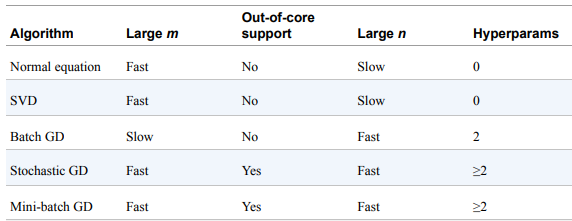

(The resulting models will be very similar)

## Polynomial Regression
When our data is more complex than straight line, we can **use linear model to fit nonlinear data**. A way of doing it is by **adding powers of features** as new features. This is the so called **Polynomial Regression**.

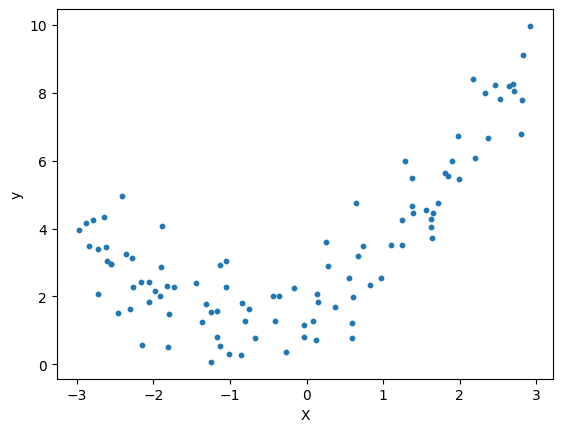

In [11]:
# Generating some nonlinear data
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

# Plotting Data
plt.scatter(X, y, s=10)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

It's clear how a straight line cannot fit this data properly. We'll use Scikit-Learn's `PolynomialFeatures` to transform our training data adding square of each feature (in this case we only have one):

In [12]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree = 2, include_bias = False)
X_poly = poly_features.fit_transform(X)

X[0], X_poly[0]

(array([-0.75275929]), array([-0.75275929,  0.56664654]))

`X_poly` now contains both original feature and its square. Let's use it to fit a Linear Regression:

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

Not bad, the model estimated:
$$ \hat y = 0.56 x_1^2 + 0.93 x_1 + 1.78$$
when the real function was:
$$ y = 0.5 x_1^2 + 1 x_1 + 2 + G_n$$

Let's use this for making predictions:

In [14]:
y_predict = lin_reg.predict(X_poly)

And plot it:

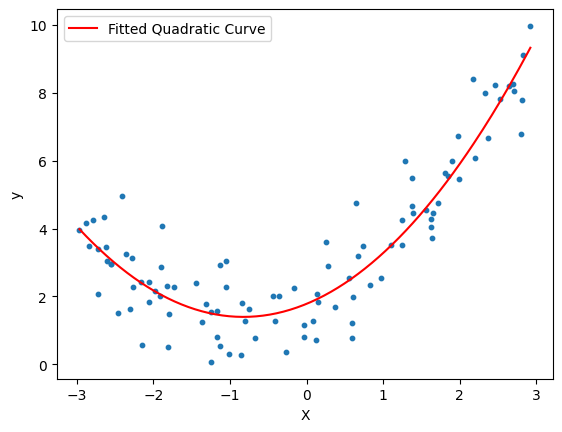

In [15]:
# Predict for plotting (smooth curve)
x_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
x_range_poly = poly_features.transform(x_range)
y_pred = lin_reg.predict(x_range_poly)

# Plot
plt.scatter(X, y, s = 10)
plt.plot(x_range, y_pred, '-r', label='Fitted Quadratic Curve')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

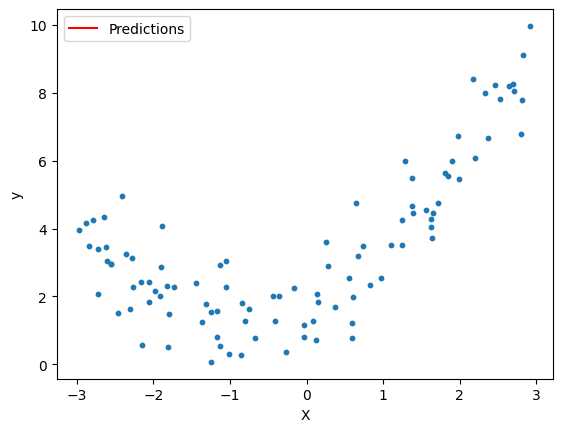

In [16]:
# Sort X and corresponding predictions
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices].flatten()
y_predict_sorted = y_predict[sorted_indices].flatten()

# Plot
plt.plot(X_sorted, y_predict_sorted, 'r-', label='Predictions')  # Smooth curve
plt.scatter(X, y, s=10)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

Note how `PolynomialFeatures` introduces **combinations of features**: when there is more than 1 feature, it adds each possible combination up to the given degree (e.g., with `degree = 2` and features $a$ and $b$, it would add the features $a^2, a^3, b^2, b^3$ but also the combinations $ab, a^2b, ab^2$)

## Learning Curves
Performing high-degree polynomial regression will likely fit training data much better than with plain linear regression:

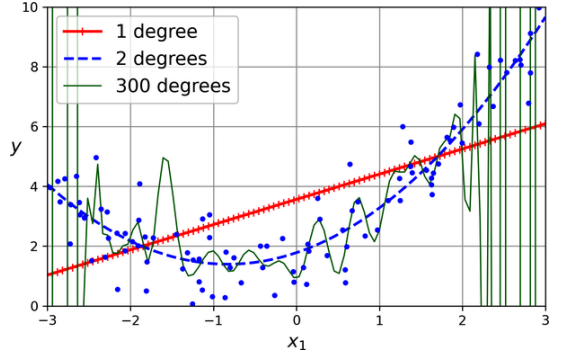

Above we can see 2 clear examples of:
- **Overfitting** (300 degrees curve);
- **Underfitting** (1 degree curve).

The model that will generalize best here is the 2 degree one. But, how to effectively spot Overfitting and Underfitting?

- using **Cross-Validation**: 
  - if model yields good metrics with training data and not with cross-validated metrics, then it is overfitting (model is too complex);
  - if model performs poorly on both, then it is underfitting (model is too simple).
- looking at the **Learning Curves**: these are plots of the model's training and validation error as function of training iteration (if incremental learning is possible, this can be done along with `partial_fit()` or `warm_start` to avoid to wait for the full training). Scikit-Learn provides a `learning_curve()` function which automatically trains and evaluates model with CV with gradually growing subsets of training set (if incremental learning is possible, `exploit_incremental_learning = True` allows using it).

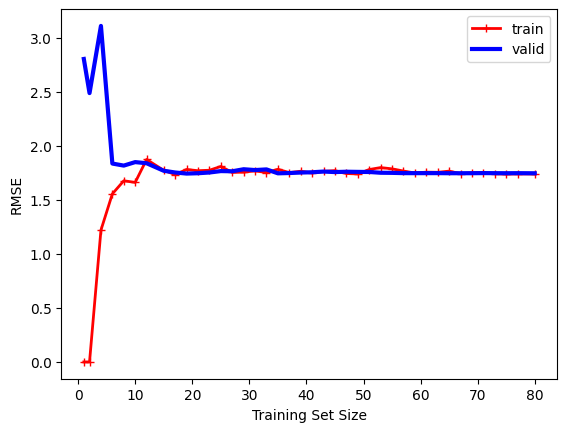

In [17]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv = 5, scoring = 'neg_root_mean_squared_error'
)
train_errors = -train_scores.mean(axis = 1)
valid_errors = -valid_scores.mean(axis = 1)

plt.plot(train_sizes, train_errors, 'r-+', linewidth = 2, label = 'train')
plt.plot(train_sizes, valid_errors, 'b-', linewidth = 3, label = 'valid')
plt.legend()
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.show()

About the above plot:
- training error: when there are few instances in the training set, the model fits them perfectly (training error = 0), but when instances are added, the error reaches a plateu; 
- validation error: when there are few instances in the training set, the model can't generalize properly; wen instances are added, the model learns and validation error slowly goes down, but it reaches the same plateu.

This is a clear case of **Underfitting**, cause both curves reaches a plateu and they are close and fairly high; in this case, adding new training example won't help: we need a better model or better features.

If we try a 10-degree polynomial we would obtain this:

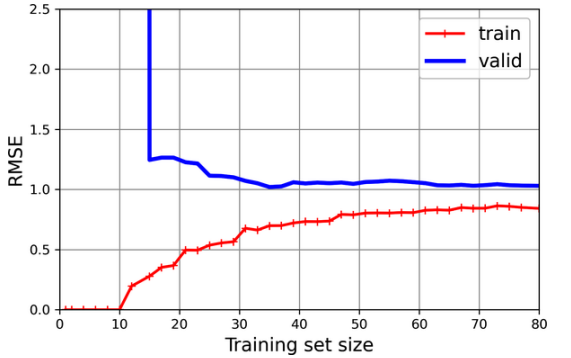

Now, the training error is lower than before and there's a gap between the 2 curves.

This is a clear case of **Overfitting**; in this case, adding new training examples would take the 2 curves to get continuously closer.

## Bias/Variance Trade-Off
The model generalization error can be expressed as the sum of 3 errors:
- **Bias**: is due to wrong assumptions (e.g., assuming data is linear when it's quadratic); high bias likely takes to underfitting;
- **Variance**: is due to model's excessive sensitivity to small variations in training data (i.e., high degrees of freedom); high variance likely takes to overfitting;
- **Irreducible Error**: is due to the noisiness of data itself; only way to solve this is to clean up data (e.g., fix data sources, sensors, outliers...)

Notice how increasing model's complexity will typically increase its variance and reduce its bias, and viceversa; this is known as **Bias/Variance Trade-Off**.

## Regularized Linear Models
A way of reducing overfitting is **Regularization** (i.e., adding constraints to a model). Before regularization, it is a good practice to scale the data, since most regularized models are sensitive to the scale of features. 

A simple way to regularize a polynomial model is by **reducing the number of polynomial degrees**.

A simple way to regularize a linear model is to **add constraints to the weights of the model**; let's look at 3 different models which implement this idea:

#### Ridge Regression
It's a **regularized version of linear regression** obtained by adding to the MSE a **regularization term**, so that the cost function becomes:

$$J(\theta) = MSE(\theta) + \frac \alpha m \sum_{i = 1}^n \theta_i^2$$

where:
- $\alpha$ is the hyperparameter controlling how much you want to regularize:
  - $\alpha = 0$ takes to standard linear regression;
  - $\alpha$ very large takes all weights close to 0 and resulting line becomes a flat line going throught he data's mean
- $\sum_{i = 1}^n \theta_i^2$ starts from 1, not 0, meaning the bias term $\theta_0$ is not regularized.

The effect of including this regularization term is that the learning algorithms is forced to both fit the data and also keep the model weights as small as possible.

Note: the regularization term is used only during training; once the model is trained, the standard MSE (or RMSE) should be used to evaluate the models' performance.

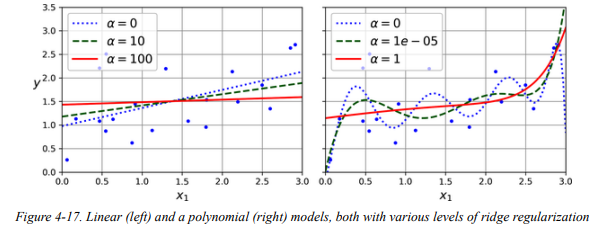

As for Linear Regression, we can implement Ridge by using closed-form equation or gradient descent (with same pros and cons); let's see how to implement it with Scikit-Learn using a closed-form solution:

In [18]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha = 0.1, solver = 'cholesky')
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([4.82899748])

Or using SGD: here the `penalty = 'l2'` means to add to the MSE a regularization term equal to alpha times the square of the $l_2$ norm of the weight vector, which is similar to ridge regression, except there's no division by $m$ (so we add `alpha = 0.1 / m` to get same as `Ridge(alpha = 0.1)`):

In [19]:
sgd_ridge_reg = SGDRegressor(penalty = 'l2', alpha = 0.1 / m, tol = None, max_iter = 1000, eta0 = 0.01, random_state=42)
sgd_ridge_reg.fit(X, y.ravel())
sgd_ridge_reg.predict([[1.5]])

array([4.82830117])

Notice how there's also a `RidgeCV` class, which performs Ridge Regression automatically tuning hyperparameters using CV (it's like a `GridSearchCV`, but optimized for Ridge so it runs much faster). Several other estimators have these CV variants.

#### Lasso (Least Absolute Shrinkage and Selection Operator) Regression
It's another **regularized version of linear regression** obtained by adding to the MSE a **regularization term**; while Ridge adds the square of the $l_2$ norm (multiplied by $\alpha / m$), Lasso adds the $l_1$ norm (multiplied by $2 \alpha$), so that the cost function becomes:

$$J(\theta) = MSE(\theta) + 2 \alpha \sum_{i = 1}^n |\theta_i|$$

(Note that the terms $\alpha / m$ (for Ridge) and $2 \alpha$ (for Lasso) have been added to guarantee that optimal $\alpha$ value is independent from the training set size)

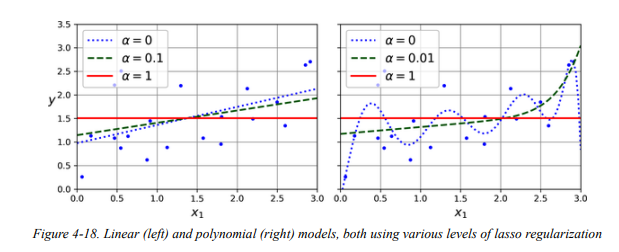

A cool characteristic of Lasso is that it tends to eliminate (i.e., set to 0) weights of least important features, allowing it to automatically performs feature selection. Below a graphical comparison of Lasso and Ridge:

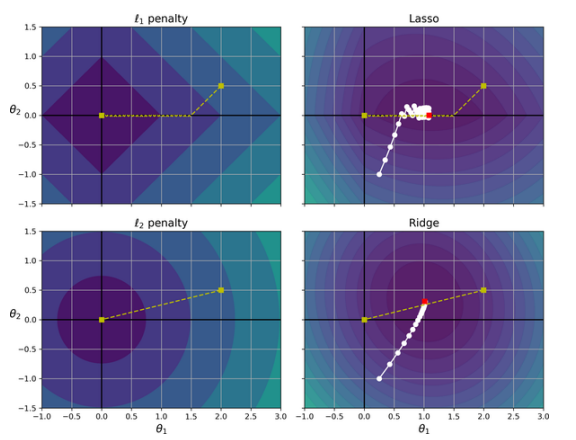

Here:
- axes are 2 model parameters;
- contours are different loss functions;
- white cirlces show the path that gradient descent takes;
- red square is global optimum;
- yellow line shows how the global optimum would change by changing $\alpha$.

Also Lasso can be implemented both with closed-form and Gradient Descent; note how Lasso cost function is not differentiable at $\theta_i = 0 \text{ for } i = 1, 2, ..., n$, so we instead use a **subgradient vector** $g$ instead when any $\theta_i = 0$:
$$g(\theta, J) = \nabla_\theta MSE(\theta) + 2 \alpha 
\begin{pmatrix}
    sign (\theta_1) \\
    sign (\theta_2) \\
    \vdots \\
    sign (\theta_n)
\end{pmatrix} 
\text{ where } sign(\theta_i) =
\begin{cases}
    -1 & \text{ if } \theta_i < 0 \\
    0 & \text{ if } \theta_i = 0 \\
    1 & \text{ if } \theta_i > 0
\end{cases}$$

Implementing Lasso in Scikit-Learn with closed-form:

In [20]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha = 0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.77621741])

(Use `SGDRegressor(penalty = 'l1', alpha = 0.1)` for SGD version; use `LassoCV()` for hyperparameters tuning)

#### Elastic Net Regression
It is a **middle ground** between Ridge and Lasso, since the regularization term is a weighted sum of the 2 regularization terms used in these 2:
$$J(\theta) = MSE(\theta) + r(2 \alpha \sum_{i = 1}^n |\theta_i|) + (1-r)(\frac \alpha m \sum_{i = 1}^n \theta_i^2)$$
where:
- $r$ is the mix ratio allowing to control the effect:
  - $r = 0$ -> ridge regression;
  - $r = 1$ -> lasso regression.

Here is how to implement it with closed-form (`l1_ratio` is $r$):

In [21]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([4.78114505])

### Linear Regression vs Ridge vs Lasso vs ElasticNet
So, when to use which? The idea is that it is almost always preferable to have at least little bit of regularization, so Linear Regression is usually avoided; Ridge is a good default option, while Lasso or ElasticNet should be used if we suspect that only some features are useful (ElasticNet is usually preferred cause Lasso may behave erratically in some situations).

### Early Stopping
Another way of regularizing iterative learning algorithms (e.g., GD) is to stop training as soon as validation error reaches a minimum; this is called **Early Stopping**. This can be used in cases in which both training and validation error go down, but after a while the validation error stops decreasing and starts going up (this is a clear sign of overfitting).

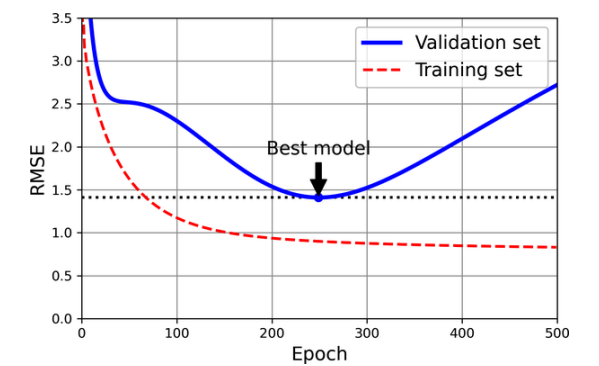

Here a basic implementation:

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from copy import deepcopy
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
preprocessing = make_pipeline(PolynomialFeatures(degree = 90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.fit_transform(X_valid)
sgd_reg = SGDRegressor(penalty = None, eta0 = 0.002, random_state = 42)
n_epochs = 500
best_valid_rmse = float('inf')

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train.ravel())
    y_valid_pred = sgd_reg.predict(X_valid_prep)
    val_error = mean_squared_error(y_valid, y_valid_pred)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

## Logistic Regression
It is a binary classifier which estimates the probability that an instance belongs to a particular class; if this probability is greater than a threshold (generally 50%), it is assigned to that class (the positive class) otherwise it is not (so it is assigned to the negative class).

### How does Logistic Regression estimate Probabilities?
Like Linear Regression, it computes a weighted sum of the input features (plus a bias term), but then it outputs the **logistic**  of the result:

$$ \hat p = h_\theta (x) = \sigma (\theta^T x)$$

where $\sigma$ is the **sigmoid function** defined as so:
$$ \sigma (t) = \frac{1}{1+exp(-t)}$$

What it does is taking any input $t$ and returning a number between 0 and 1 (i.e., a probability).

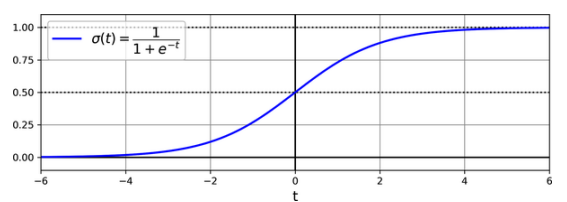

This probability is then used to make prediction:

$$\hat y = 
\left\{
\begin{array}{l}
0 & \text{if } \hat p < 0.5 \\
1 & \text{if } \hat p \ge 0.5
\end{array}
\right.$$

$t$ is called the **logit**: this comes from the **logit function**, which is the inverse of the logistic function:
$$ logit(p) = log(\frac{p}{1-p})$$

### Training and Cost Function
Our aim is to set parameter $\theta$ so that model estimates high probabilities for positive instances and low for negative instances. This is done by using the **cost function for a single training instance** $x$:

$$ c(\theta) = 
\left\{
\begin{array}{l}
- log(\hat p) & \text{if } y = 1 \\
- log(1- \hat p) & \text{if } y = 0
\end{array}
\right.$$

It's easy to check that:
- $-log(t)$ grows very large when $t$ approaches 0 (i.e., cost is high when probability close to 0 for a positive instance or close to 1 for a negative instance)
- $-log(t)$ is close to 0 when $t$ is close to 1 (i.e., cost is low when probability close to 1 for positive instance or close to 0 for negative instance).

The **cost function** over the whole training set is the average of the cost over all the training instances, which is called **log loss**:

$$ J(\theta) = - \frac1m \sum_{i=1}^m [y^{(i)}log(\hat p^{(i)}) + (1- y^{(i)})log(1- \hat p^{(i)})]$$

Differently from Linear Regression, there's no closed-form equation to compute $\theta$; luckily, this cost function is convex, so gradient descent is guaranteed to find the global minimum (if lr is not too large).

The **partial derivatives** of the cost function with reguard to the $j^{th}$ model parameter $\theta_j$ are:

$$ \frac{\partial}{\partial \theta_j} J(\theta) = \frac 1 m \sum_{i=1}^m(\sigma(\theta^Tx^{(i)})- y^{(i)})x_j^{(i)}$$

(this is very similar to the one of Linear Regression)

### Decision Boundaries
Let's use the **Iris Dataset** to perform Logistic Regression:

In [23]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame = True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [24]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [25]:
iris.target.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [26]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Let's now split into train and test set and train a logistic regression (we will use the petal width as unique predictor trying to predict if target is "virginica" or not):

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = iris.data[['petal width (cm)']].values
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Let's now check the estimated probabilities for flowers with petal width between 0 and 3 cm:

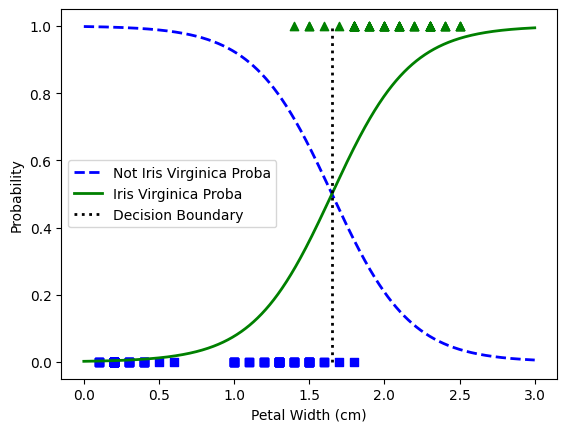

In [28]:
import numpy as np
import matplotlib.pyplot as plt

X_new = np.linspace(0, 3, 1000).reshape(-1, 1) #reshape to get column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]
triangles = np.where(y == True)
squares = np.where(y == False)

plt.plot(X_new, y_proba[:, 0], 'b--', linewidth = 2, label = 'Not Iris Virginica Proba')
plt.plot(X_new, y_proba[:, 1], 'g-', linewidth = 2, label = 'Iris Virginica Proba')
plt.plot([decision_boundary, decision_boundary], [0, 1], 'k:', linewidth = 2, label = 'Decision Boundary')
plt.scatter(x = X[squares], y = np.zeros(len(squares[0])), marker = 's', color = 'b')
plt.scatter(x = X[triangles], y = np.ones(len(triangles[0])), marker = '^', color = 'g')


plt.legend()
plt.xlabel('Petal Width (cm)')
plt.ylabel('Probability')
plt.show()

Denoting with Green Triangles the Iris Virginica and with Blue Squares other Iris flowers, we can see how Iris Virginica's petal width ranges from 1.4 to 2.5 cm, while the other Iris generally from 0.1 to 1.8 cm (there's a bit of overlap). By looking at that, we can say that classifier is highly confident that with petal width above 2 cm the instance is an Iris Virginica (so high prob for that instance is outputted) while below 1 cm it is highly confidend that is not an Iris Virginica (so low prob). So, we have a decision boundary at around 1.6 cm:

In [29]:
decision_boundary

np.float64(1.6516516516516517)

In [30]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])

With another visualization, we can prove that this boundary is linear:

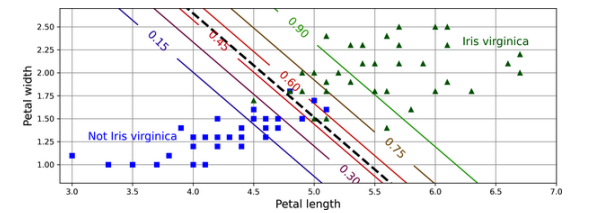

### Regularization
Logistic Regression can be regularized; Scikit-Learn adds an $l_2$ penalty by default; while in other linear models we use the hyperparameter *alpha* for regularization, in the LogisticRegression we use its inverse: *C* (higher *C* is, less the model is regulrized).

### Softmax Regression
We saw that Logistic Regression is a binary classifier; by the way, the model can be generalized to support multiple classes directly, without the need to combine multiple binary classifier. This generalization is called **Softmax Regression** (or **Multinomial Logistic Regression**).

The idea is that given an instance $x$, the model computes a score $s_k(x)$ for each class $k$ using the same formula of Linear and Logistic Regressions:

$$s_k(x) = (\theta^{(k)})^Tx$$

where each class has its own parameter vector $\theta^{(i)}$.


Then, it estimates the probability of each class $\hat p_k$ by applying the **Softmax Function** (or **Normalized Exponential**) to the score:

$$\hat p_k = \sigma(s(x))_k = \frac{exp(s_k(x))}{\sum_{j=1}^{K}exp(s_j(x))}$$

where:
- $K$ is number of classes;
- $s(x)$ is the vector of scores of each class for instance $x$;
- $\sigma(s(x))_k$ is the estimated probability that instance $x$ belongs to class $k$ given the scores of each class $s(x)$.

The predicted class is then the one with the highest associated estimated probability:

$$ \hat y = argmax_k \sigma(s(x))_k = argmax_k s_k(x) = argmax_k ((\theta^{(k)})^Tx)

The goal is the same as before, so the cost-function is now the **Cross Entropy Cost Function**:

$$J(\Theta) = - \frac 1 m \sum_{i = 1}^{m}\sum_{k = 1}^{K} y_k^{(i)}log(\hat p_k^{(i)}) $$

This measures the difference between the predicted probabilities and the actual class labels. The gradient vector of this function with regard to $\theta^{(k)}$ is:

$$ \nabla_{\theta^{k}}J(\Theta) = \frac 1 m \sum_{i = 1}^m(\hat p_k^{(i)} - y_k^{(i)})x^{(i)}$$

Scikit-Learn's *LogisticRegression* automatically uses softmax to train a classifier with more than 2 classes (again you can control regularization, which is applied by default, with the $C$ hyperparameter):

In [31]:
X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = iris['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C = 30, random_state=42)
softmax_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,30
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


The decision boundaries are now these:

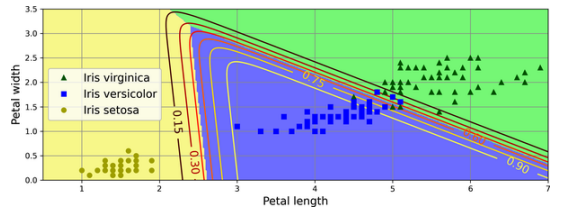